Loading from cache...
Total goals: 924


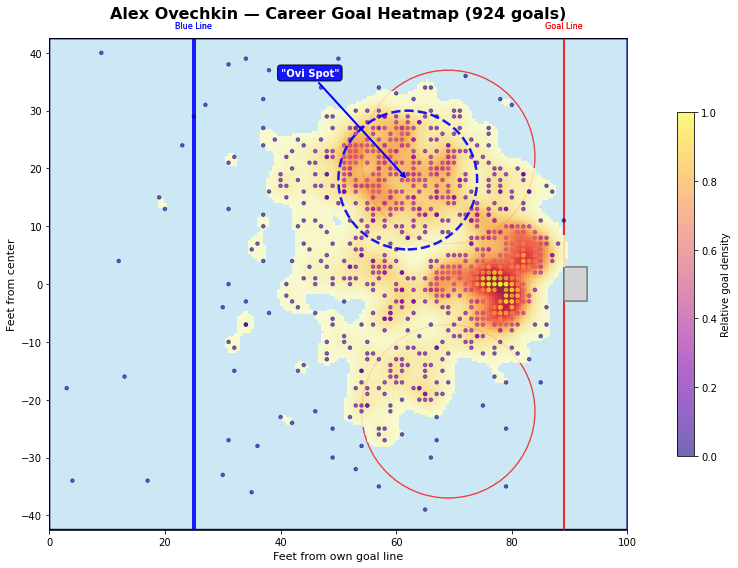

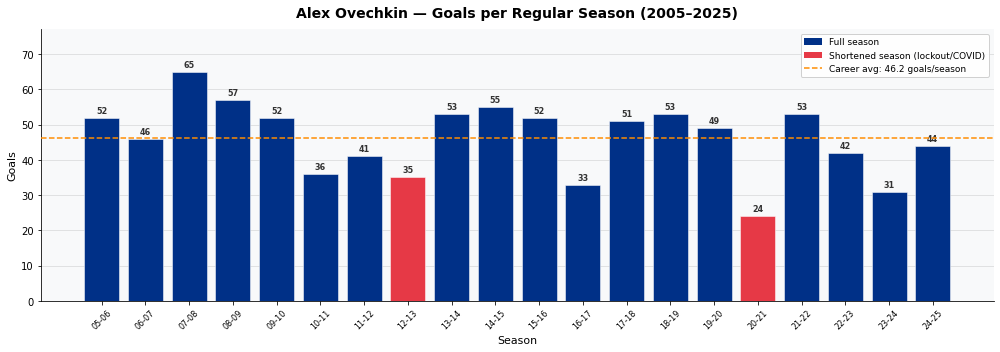

Bar chart saved.


In [4]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import gaussian_kde
import pandas as pd
import json
import os

CACHE_FILE = "ovechkin_goals.json"

def get_ovechkin_goals():
    if os.path.exists(CACHE_FILE):
        print("Loading from cache...")
        with open(CACHE_FILE, "r") as f:
            return json.load(f)

    player_id = 8471214
    goals = []
    seasons = [
        "20052006","20062007","20072008","20082009","20092010",
        "20102011","20112012","20122013","20132014","20142015",
        "20152016","20162017","20182019","20192020",
        "20202021","20212022","20222023","20232024","20242025"
    ]

    for season in seasons:
        print(f"Fetching season {season}...")
        url = f"https://api-web.nhle.com/v1/player/{player_id}/game-log/{season}/2"
        try:
            res = requests.get(url, timeout=10).json()
            for game in res.get("gameLog", []):
                game_id = game["gameId"]
                pbp = requests.get(
                    f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play",
                    timeout=10
                ).json()
                for play in pbp.get("plays", []):
                    if play.get("typeDescKey") == "goal":
                        details = play.get("details", {})
                        if details.get("scoringPlayerId") == player_id:
                            x = details.get("xCoord")
                            y = details.get("yCoord")
                            if x is not None and y is not None:
                                goals.append({
                                    "x": x, "y": y,
                                    "season": season
                                })
        except Exception as e:
            print(f"  Skipping {season}: {e}")

    with open(CACHE_FILE, "w") as f:
        json.dump(goals, f)
    print(f"Done. {len(goals)} goals saved to cache.")
    return goals

def draw_rink(ax):
    ax.set_facecolor("#cce8f4")

    rink = patches.FancyBboxPatch((0, -42.5), 100, 85,
        boxstyle="round,pad=0", linewidth=2,
        edgecolor="navy", facecolor="#cce8f4", zorder=0)
    ax.add_patch(rink)

    ax.axvline(x=89, color='red', linewidth=1.5, alpha=0.8, zorder=1)
    ax.text(89, 44, 'Goal Line', ha='center', va='bottom', fontsize=8,
            color='red', alpha=0.9)

    ax.axvline(x=25, color='blue', linewidth=4, alpha=0.65, zorder=1)
    ax.text(25, 44, 'Blue Line', ha='center', va='bottom', fontsize=8,
            color='blue', alpha=0.9)

    for cx, cy in [(69, 22), (69, -22)]:
        ax.add_patch(plt.Circle((cx, cy), 15, fill=False,
                                color='red', linewidth=1.2, alpha=0.5, zorder=1))

    ax.add_patch(patches.Rectangle(
        (89, -3), 4, 6,
        linewidth=1.5, edgecolor='gray',
        facecolor='lightgray', alpha=0.9, zorder=1))

def draw_heatmap(ax, x, y):
    kde = gaussian_kde([x, y], bw_method=0.12)
    xi, yi = np.mgrid[0:100:200j, -42.5:42.5:200j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    zi_masked = np.ma.masked_where(zi < zi.max() * 0.05, zi)
    ax.pcolormesh(xi, yi, zi_masked, cmap='YlOrRd', alpha=0.85,
                  shading='auto', zorder=2)

def color_dots_by_density(ax, x, y):
    kde = gaussian_kde([x, y], bw_method=0.12)
    density = kde(np.vstack([x, y]))
    density_norm = (density - density.min()) / (density.max() - density.min())
    sc = ax.scatter(x, y,
                    c=density_norm,
                    cmap='plasma',
                    alpha=0.6,
                    s=12,
                    zorder=3)
    plt.colorbar(sc, ax=ax, label='Relative goal density', shrink=0.7)

def draw_season_bar_chart(df):
    # Count goals per season
    season_counts = df.groupby('season').size().reset_index(name='goals')

    # Format season labels
    season_counts['label'] = season_counts['season'].apply(
        lambda s: f"{s[2:4]}-{s[6:8]}"
    )

    # Color bars(highlight lockout/covid seasons)
    bar_colors = []
    for s in season_counts['season']:
        if s == "20122013":  # lockout shortened
            bar_colors.append('#e63946')
        elif s == "20202021":  # covid shortened
            bar_colors.append('#e63946')
        else:
            bar_colors.append('#003087')

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#f8f9fa')

    bars = ax.bar(season_counts['label'], season_counts['goals'],
                  color=bar_colors, edgecolor='white', linewidth=0.5, zorder=3)

    # Add value labels on top of each bar
    for bar, val in zip(bars, season_counts['goals']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                str(val), ha='center', va='bottom', fontsize=8,
                color='#333333', fontweight='bold')

    # Average line
    avg = season_counts['goals'].mean()
    ax.axhline(y=avg, color='darkorange', linewidth=1.5,
               linestyle='--', zorder=4, label=f'Career avg: {avg:.1f} goals/season')

    ax.set_xlabel("Season", fontsize=11)
    ax.set_ylabel("Goals", fontsize=11)
    ax.set_title("Alex Ovechkin — Goals per Regular Season (2005–2025)",
                 fontsize=14, fontweight='bold', pad=12)

    ax.set_ylim(0, max(season_counts['goals']) + 12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend for shortened seasons
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#003087', label='Full season'),
        Patch(facecolor='#e63946', label='Shortened season (lockout/COVID)'),
        plt.Line2D([0], [0], color='darkorange', linewidth=1.5,
                   linestyle='--', label=f'Career avg: {avg:.1f} goals/season')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
              framealpha=0.9)

    plt.tight_layout()
    plt.savefig("ovechkin_bar_chart.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Bar chart saved.")


goals = get_ovechkin_goals()
df = pd.DataFrame(goals)

df['x_norm'] = df['x'].abs()
df['y_norm'] = df.apply(lambda r: r['y'] if r['x'] > 0 else -r['y'], axis=1)

print(f"Total goals: {len(df)}")

#Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

draw_rink(ax)
draw_heatmap(ax, df['x_norm'].values, df['y_norm'].values)
draw_rink(ax)
color_dots_by_density(ax, df['x_norm'].values, df['y_norm'].values)

ax.set_xlim(0, 100)
ax.set_ylim(-42.5, 42.5)
ax.set_aspect('equal')
ax.set_xlabel("Feet from own goal line", fontsize=11)
ax.set_ylabel("Feet from center", fontsize=11)
ax.set_title(f"Alex Ovechkin — Career Goal Heatmap ({len(df)} goals)",
             fontsize=16, fontweight='bold', pad=20)

ax.annotate('"Ovi Spot"', xy=(62, 18), xytext=(40, 36),
            fontsize=10, color='white', fontweight='bold',
            bbox=dict(boxstyle='round', fc='blue', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

ax.add_patch(patches.Ellipse(
    (62, 18), width=24, height=24,
    linewidth=2.5, edgecolor='blue',
    facecolor='none', linestyle='--',
    alpha=0.9, zorder=5))

plt.tight_layout()
plt.savefig("ovechkin_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar chart
draw_season_bar_chart(df)

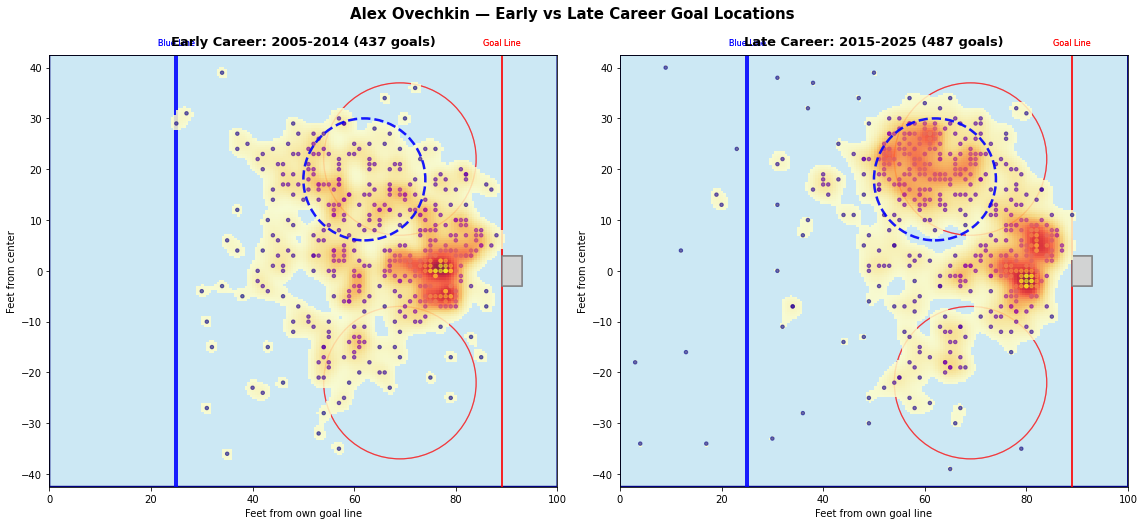

Comparison chart saved.


In [5]:
# Early vs Late Career Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

early = df[df['season'] <= '20132014']
late = df[df['season'] > '20132014']

def draw_comparison(ax, data, title):
    draw_rink(ax)

    kde = gaussian_kde([data['x_norm'].values, data['y_norm'].values], bw_method=0.12)
    xi, yi = np.mgrid[0:100:200j, -42.5:42.5:200j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    zi_masked = np.ma.masked_where(zi < zi.max() * 0.05, zi)
    ax.pcolormesh(xi, yi, zi_masked, cmap='YlOrRd', alpha=0.85,
                  shading='auto', zorder=2)

    draw_rink(ax)

    density = kde(np.vstack([data['x_norm'].values, data['y_norm'].values]))
    density_norm = (density - density.min()) / (density.max() - density.min())
    ax.scatter(data['x_norm'], data['y_norm'],
               c=density_norm, cmap='plasma',
               alpha=0.6, s=12, zorder=3)

    ax.add_patch(patches.Ellipse(
        (62, 18), width=24, height=24,
        linewidth=2.5, edgecolor='blue',
        facecolor='none', linestyle='--',
        alpha=0.9, zorder=5))

    ax.set_xlim(0, 100)
    ax.set_ylim(-42.5, 42.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Feet from own goal line", fontsize=10)
    ax.set_ylabel("Feet from center", fontsize=10)

draw_comparison(axes[0], early, f"Early Career: 2005-2014 ({len(early)} goals)")
draw_comparison(axes[1], late,  f"Late Career: 2015-2025 ({len(late)} goals)")

fig.suptitle("Alex Ovechkin — Early vs Late Career Goal Locations",
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig("ovechkin_early_vs_late.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")